## Sharewell B. Chingwingwi

Titanic Dataset: EDA and Machine-Learning Project

In [110]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import warnings

warnings.filterwarnings("ignore")

PALETTE = "Set2"
FIG_COLOR = "#f9f9f9"
sns.set_theme(style="whitegrid", palette=PALETTE)
plt.rcParams.update({"figure.facecolor": FIG_COLOR, "axes.facecolor": FIG_COLOR,
                     "font.family": "DejaVu Sans", "figure.dpi": 150})

DATA_PATH = "Titanic-Dataset[1].csv"

df_raw = pd.read_csv(DATA_PATH)

First 10 rows

In [27]:

print(df_raw.head(10).to_string())


   PassengerId  Survived  Pclass                                                 Name     Sex   Age  SibSp  Parch            Ticket     Fare Cabin Embarked
0            1         0       3                              Braund, Mr. Owen Harris    male  22.0      1      0         A/5 21171   7.2500   NaN        S
1            2         1       1  Cumings, Mrs. John Bradley (Florence Briggs Thayer)  female  38.0      1      0          PC 17599  71.2833   C85        C
2            3         1       3                               Heikkinen, Miss. Laina  female  26.0      0      0  STON/O2. 3101282   7.9250   NaN        S
3            4         1       1         Futrelle, Mrs. Jacques Heath (Lily May Peel)  female  35.0      1      0            113803  53.1000  C123        S
4            5         0       3                             Allen, Mr. William Henry    male  35.0      0      0            373450   8.0500   NaN        S
5            6         0       3                                

Dataset Shape

In [28]:

print(f"  Rows   : {df_raw.shape[0]}")
print(f"  Columns: {df_raw.shape[1]}")



  Rows   : 891
  Columns: 12


Column Data Types

In [17]:

print(df_raw.dtypes.to_string())


 Column Data Types 
PassengerId      int64
Survived         int64
Pclass           int64
Name            object
Sex             object
Age            float64
SibSp            int64
Parch            int64
Ticket          object
Fare           float64
Cabin           object
Embarked        object


Missing Values per Column

In [18]:
missing = df_raw.isnull().sum()
missing_pct = (missing / len(df_raw) * 100).round(2)
missing_df = pd.DataFrame({"Missing Count": missing, "Missing %": missing_pct})
print(missing_df[missing_df["Missing Count"] > 0].to_string())



 Missing Values per Column 
          Missing Count  Missing %
Age                 177      19.87
Cabin               687      77.10
Embarked              2       0.22



Duplicate Records

In [29]:
dupes = df_raw.duplicated().sum()
print(f"  Duplicate rows found: {dupes}")


  Duplicate rows found: 0


Summary Statistics

In [21]:

print(df_raw.describe(include="all").to_string())


  Summary Statistics 
        PassengerId    Survived      Pclass                 Name   Sex         Age       SibSp       Parch  Ticket        Fare Cabin Embarked
count    891.000000  891.000000  891.000000                  891   891  714.000000  891.000000  891.000000     891  891.000000   204      889
unique          NaN         NaN         NaN                  891     2         NaN         NaN         NaN     681         NaN   147        3
top             NaN         NaN         NaN  Dooley, Mr. Patrick  male         NaN         NaN         NaN  347082         NaN    G6        S
freq            NaN         NaN         NaN                    1   577         NaN         NaN         NaN       7         NaN     4      644
mean     446.000000    0.383838    2.308642                  NaN   NaN   29.699118    0.523008    0.381594     NaN   32.204208   NaN      NaN
std      257.353842    0.486592    0.836071                  NaN   NaN   14.526497    1.102743    0.806057     NaN   49.69342

Data Cleaning

1. Handling missing values

In [43]:
df = df_raw.copy()
age_median = df["Age"].median()
df["Age"] = df["Age"].fillna(age_median)
print(
    f"  Age   : {df_raw['Age'].isnull().sum()} nulls: filled with median ({age_median})")

df["Has_Cabin"] = df["Cabin"].notna().astype(int)
df.drop(columns=["Cabin"], inplace=True)
print("  Cabin : 687 nulls (77 %): dropped; binary 'Has_Cabin' feature created")

emb_mode = df["Embarked"].mode()[0]
df["Embarked"] = df["Embarked"].fillna(emb_mode)
print(f"  Embarked: 2 nulls: filled with mode ('{emb_mode}')")

  Age   : 177 nulls: filled with median (28.0)
  Cabin : 687 nulls (77 %): dropped; binary 'Has_Cabin' feature created
  Embarked: 2 nulls: filled with mode ('S')


2. Removing duplicates

In [44]:
before = len(df)
df.drop_duplicates(inplace=True)
print(
    f"  Rows before: {before} | Rows after: {len(df)} | Removed: {before - len(df)}")

  Rows before: 891 | Rows after: 891 | Removed: 0


3. Corrected data

In [46]:
df["Age"] = df["Age"].astype(float)
df["Survived"] = df["Survived"].astype("category")
df["Pclass"] = df["Pclass"].astype("category")
df["Sex"] = df["Sex"].astype("category")
df["Embarked"] = df["Embarked"].astype("category")
print("  Age      : float64")
print("  Survived : category")
print("  Pclass   : category")
print("  Sex      : category")
print("  Embarked : category")


  Age      : float64
  Survived : category
  Pclass   : category
  Sex      : category
  Embarked : category


Feature Engneering (added value for EDA)

In [48]:
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["IsAlone"] = (df["FamilySize"] == 1).astype(int)
df["AgeGroup"] = pd.cut(df["Age"],
                        bins=[0, 12, 18, 35, 60, 100],
                        labels=["Child", "Teen", "YoungAdult", "Adult", "Senior"])
df["FareBand"] = pd.qcut(df["Fare"], q=4,
                         labels=["Low", "Medium", "High", "Very High"])
print("  Created: FamilySize, IsAlone, AgeGroup, FareBand")

  Created: FamilySize, IsAlone, AgeGroup, FareBand


Verifying data quality

In [54]:
print(f"  Remaining nulls:\n{df.isnull().sum()[df.isnull().sum() > 0]}")
print(f"  Duplicates: {df.duplicated().sum()}")
print(f"  Final shape: {df.shape}")


  Remaining nulls:
Series([], dtype: int64)
  Duplicates: 0
  Final shape: (891, 16)


Explanatory data analysis

## Figure 1: Numerical and Categorical Distributions (Part 1)

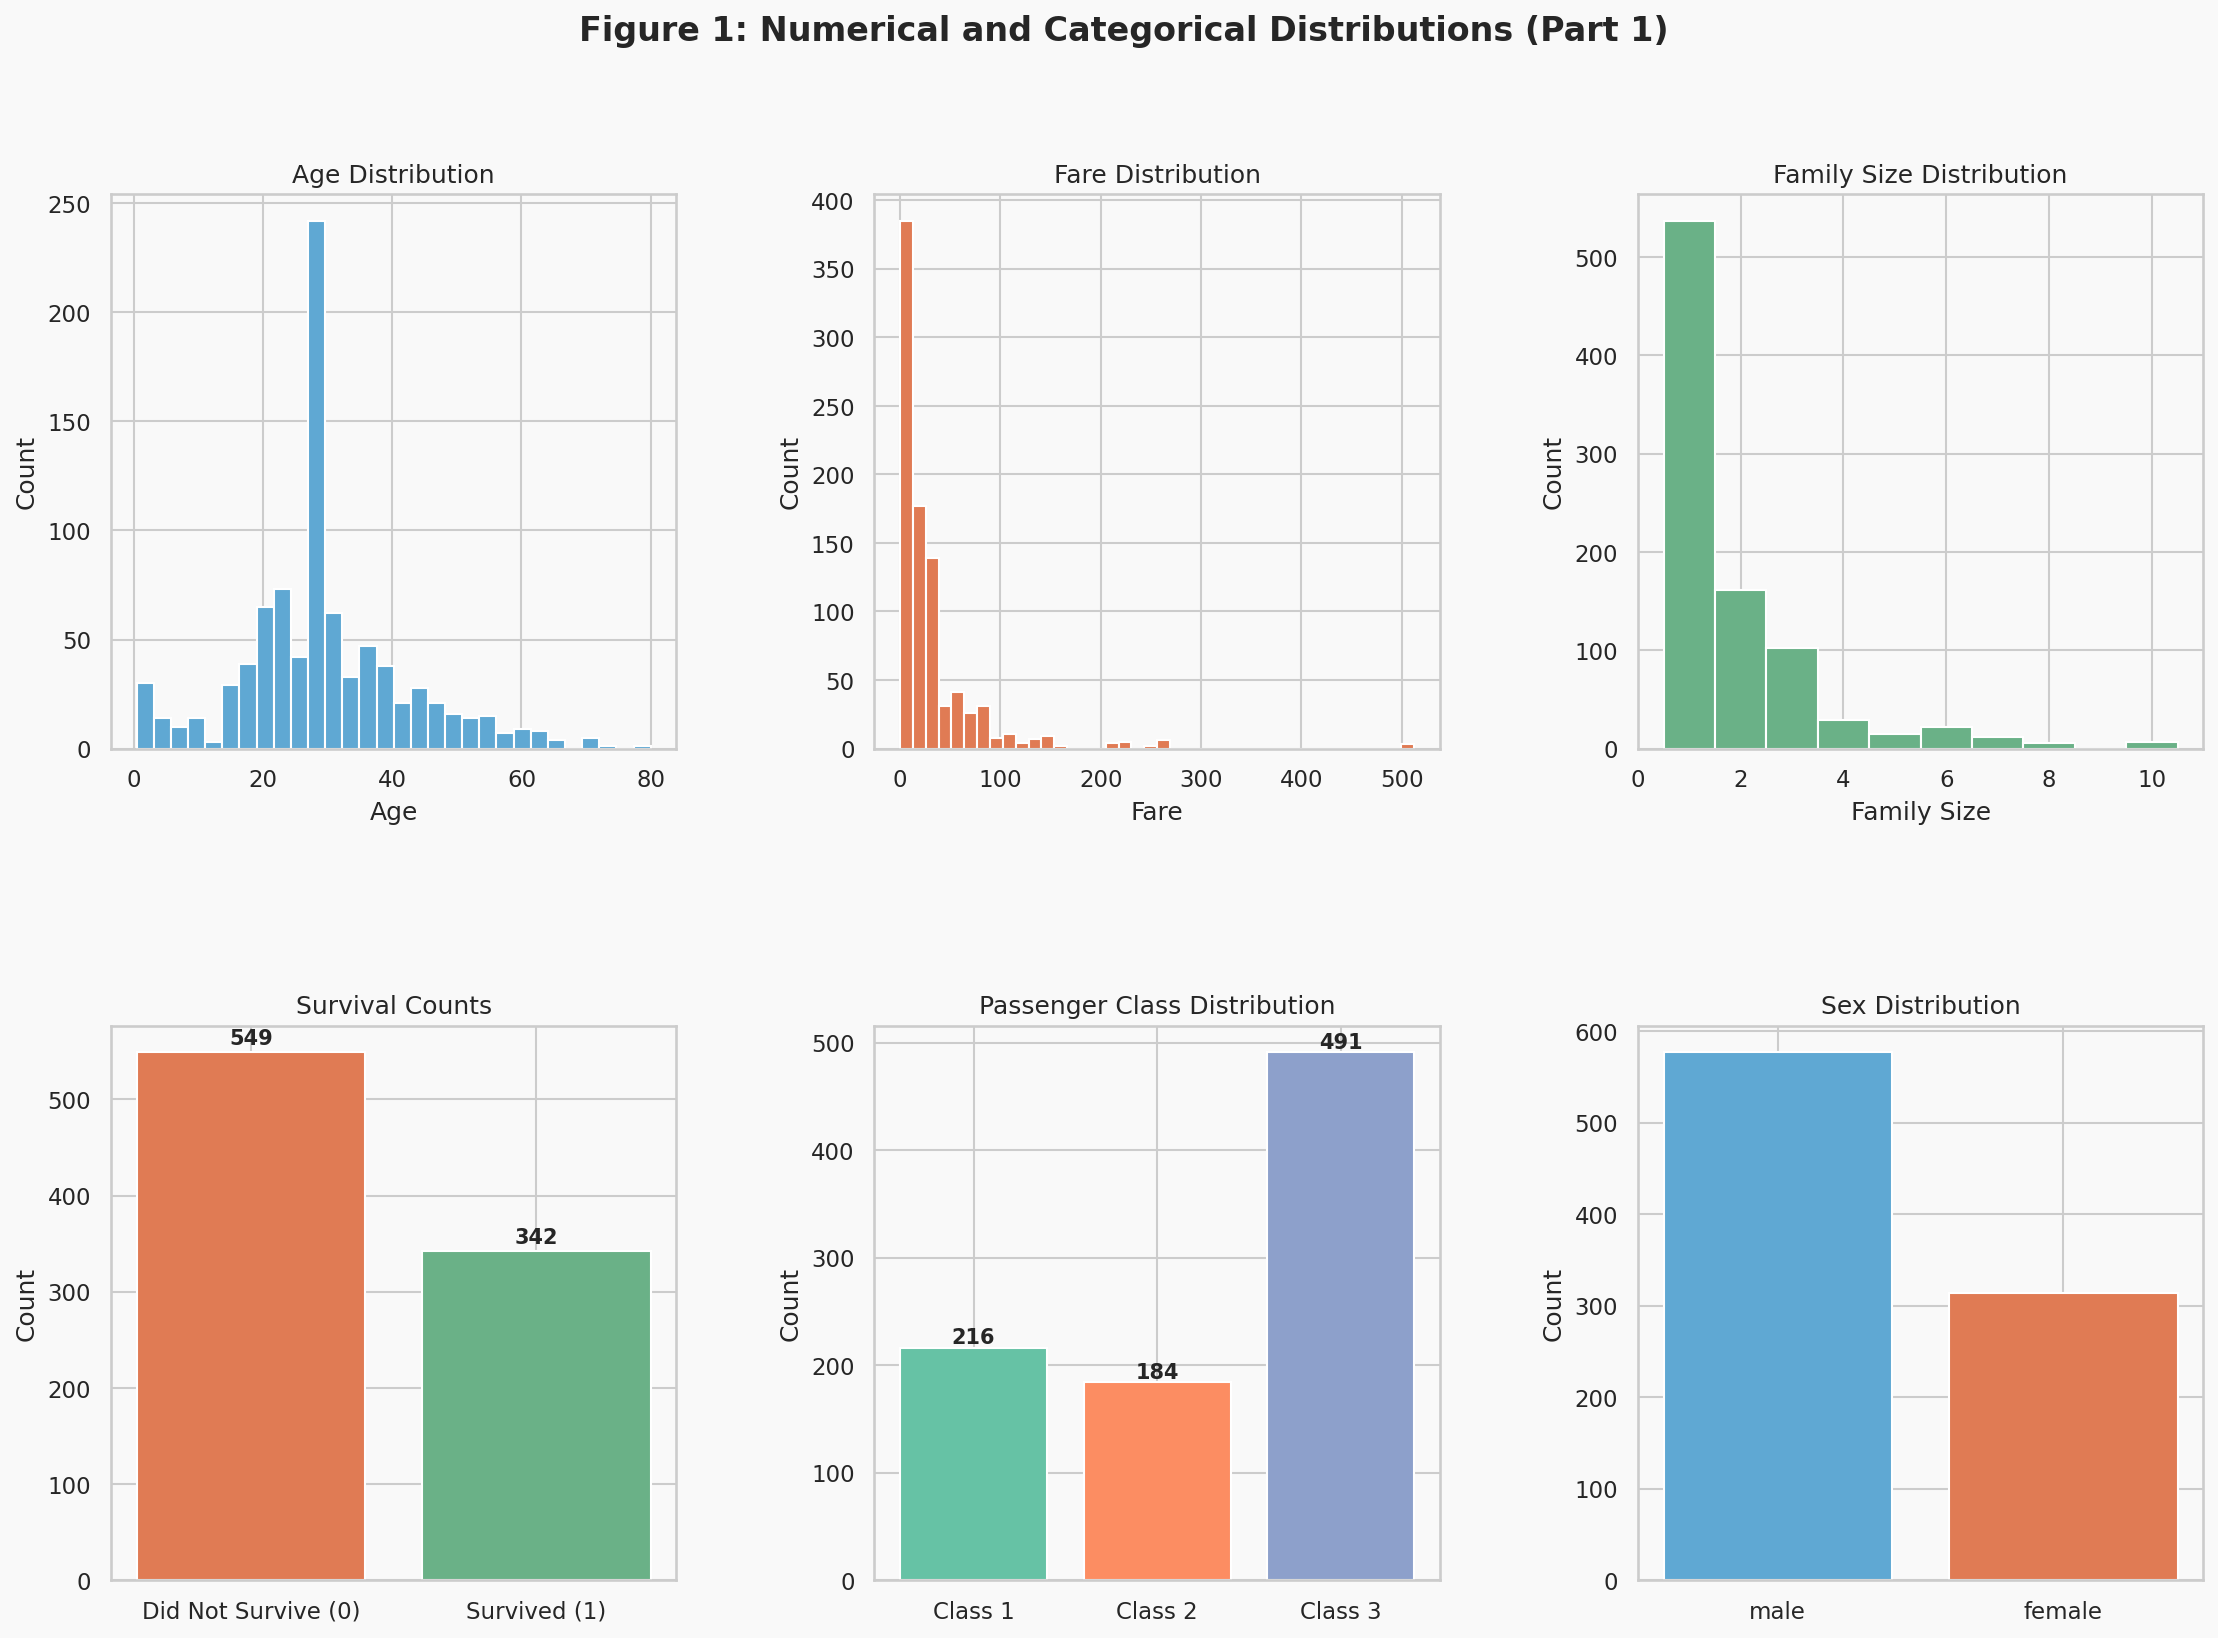

In [82]:
fig1 = plt.figure(figsize=(18, 12), facecolor=FIG_COLOR)
fig1.suptitle("Figure 1: Numerical and Categorical Distributions (Part 1)",
              fontsize=16, fontweight="bold", y=0.98)
gs1 = gridspec.GridSpec(2, 3, figure=fig1, hspace=0.5, wspace=0.35)

# Plot 1: Age histogram
ax1 = fig1.add_subplot(gs1[0, 0])
ax1.hist(df["Age"], bins=30, color="#5fa8d3", edgecolor="white")
ax1.set_title("Age Distribution")
ax1.set_xlabel("Age")
ax1.set_ylabel("Count")

# Plot 2: Fare histogram
ax2 = fig1.add_subplot(gs1[0, 1])
ax2.hist(df["Fare"], bins=40, color="#e07b54", edgecolor="white")
ax2.set_title("Fare Distribution")
ax2.set_xlabel("Fare")
ax2.set_ylabel("Count")

# Plot 3: FamilySize histogram
ax3 = fig1.add_subplot(gs1[0, 2])
ax3.hist(df["FamilySize"], bins=range(1, 12),
         color="#6ab187", edgecolor="white", align="left")
ax3.set_title("Family Size Distribution")
ax3.set_xlabel("Family Size")
ax3.set_ylabel("Count")

# Plot 4: Survived bar chart
ax4 = fig1.add_subplot(gs1[1, 0])
surv_counts = df["Survived"].value_counts().sort_index()
bars = ax4.bar(["Did Not Survive (0)", "Survived (1)"], surv_counts.values,
               color=["#e07b54", "#6ab187"], edgecolor="white")
for bar in bars:
    ax4.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 8,
             str(int(bar.get_height())), ha="center", fontsize=10, fontweight="bold")
ax4.set_title("Survival Counts")
ax4.set_ylabel("Count")

# Plot 5: Pclass bar chart
ax5 = fig1.add_subplot(gs1[1, 1])
pc_counts = df["Pclass"].value_counts().sort_index()
bars5 = ax5.bar([f"Class {c}" for c in pc_counts.index], pc_counts.values,
                color=sns.color_palette(PALETTE, 3), edgecolor="white")
for bar in bars5:
    ax5.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 4,
             str(int(bar.get_height())), ha="center", fontsize=10, fontweight="bold")
ax5.set_title("Passenger Class Distribution")
ax5.set_ylabel("Count")

# Plot 6: Sex bar chart
ax6 = fig1.add_subplot(gs1[1, 2])
sex_counts = df["Sex"].value_counts()
ax6.bar(sex_counts.index, sex_counts.values, color=[
        "#5fa8d3", "#e07b54"], edgecolor="white")
ax6.set_title("Sex Distribution")
ax6.set_ylabel("Count")

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

## Figure 2: Numerical and Categorical Distributions (Part 2)

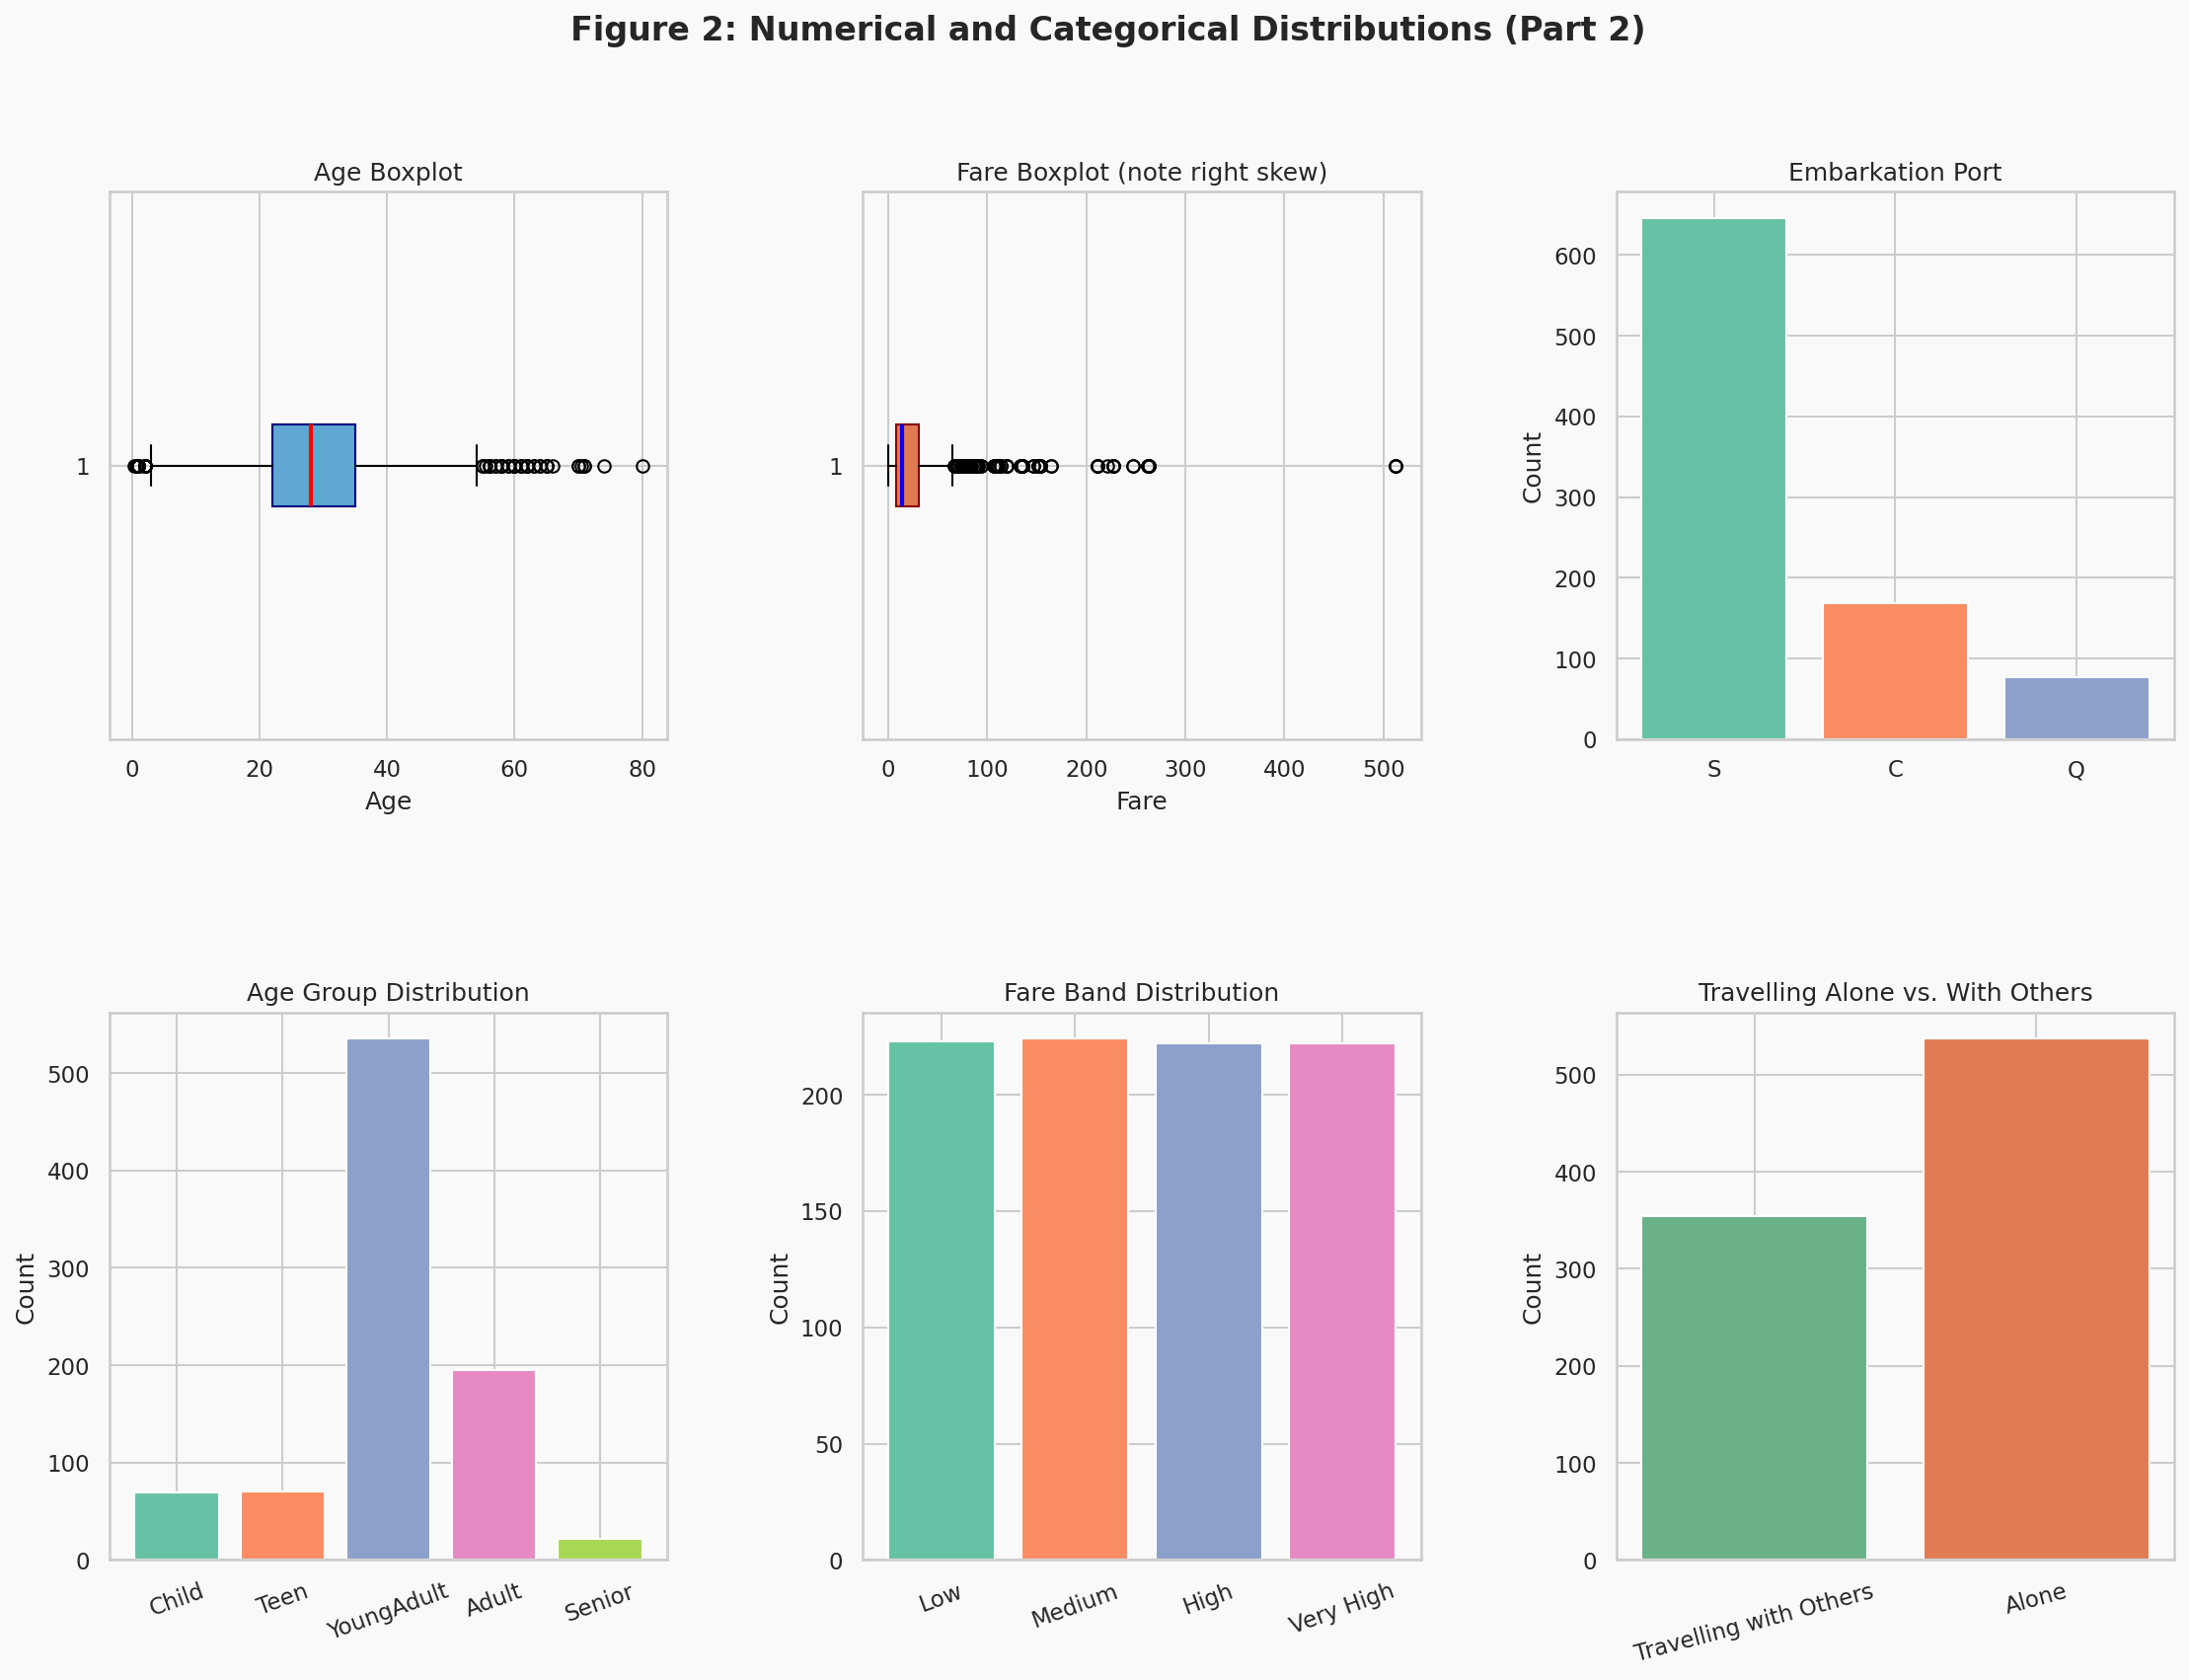

In [83]:
fig2 = plt.figure(figsize=(18, 12), facecolor=FIG_COLOR)
fig2.suptitle("Figure 2: Numerical and Categorical Distributions (Part 2)",
              fontsize=16, fontweight="bold", y=0.98)
gs2 = gridspec.GridSpec(2, 3, figure=fig2, hspace=0.5, wspace=0.35)

# Plot 7: Age boxplot
ax7 = fig2.add_subplot(gs2[0, 0])
ax7.boxplot(df["Age"], vert=False, patch_artist=True,
            boxprops=dict(facecolor="#5fa8d3", color="navy"),
            medianprops=dict(color="red", linewidth=2))
ax7.set_title("Age Boxplot")
ax7.set_xlabel("Age")

# Plot 8: Fare boxplot
ax8 = fig2.add_subplot(gs2[0, 1])
ax8.boxplot(df["Fare"], vert=False, patch_artist=True,
            boxprops=dict(facecolor="#e07b54", color="darkred"),
            medianprops=dict(color="blue", linewidth=2))
ax8.set_title("Fare Boxplot (note right skew)")
ax8.set_xlabel("Fare")

# Plot 9: Embarked bar chart
ax9 = fig2.add_subplot(gs2[0, 2])
emb_counts = df["Embarked"].value_counts()
ax9.bar(emb_counts.index, emb_counts.values,
        color=sns.color_palette(PALETTE, 3), edgecolor="white")
ax9.set_title("Embarkation Port")
ax9.set_ylabel("Count")

# Plot 10: AgeGroup bar chart
ax10 = fig2.add_subplot(gs2[1, 0])
ag_counts = df["AgeGroup"].value_counts().reindex(
    ["Child", "Teen", "YoungAdult", "Adult", "Senior"])
ax10.bar(ag_counts.index, ag_counts.values,
         color=sns.color_palette(PALETTE, 5), edgecolor="white")
ax10.set_title("Age Group Distribution")
ax10.set_ylabel("Count")
ax10.tick_params(axis="x", rotation=20)

# Plot 11: FareBand bar chart
ax11 = fig2.add_subplot(gs2[1, 1])
fb_counts = df["FareBand"].value_counts().reindex(
    ["Low", "Medium", "High", "Very High"])
ax11.bar(fb_counts.index, fb_counts.values,
         color=sns.color_palette(PALETTE, 4), edgecolor="white")
ax11.set_title("Fare Band Distribution")
ax11.set_ylabel("Count")
ax11.tick_params(axis="x", rotation=20)

# Plot 12: IsAlone bar chart
ax12 = fig2.add_subplot(gs2[1, 2])
alone_counts = df["IsAlone"].value_counts().sort_index()
ax12.bar(["Travelling with Others", "Alone"], alone_counts.values,
         color=["#6ab187", "#e07b54"], edgecolor="white")
ax12.set_title("Travelling Alone vs. With Others")
ax12.set_ylabel("Count")
ax12.tick_params(axis="x", rotation=15)

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

In [84]:
# Univariate summary stats

print(df[["Age", "Fare", "FamilySize", "SibSp", "Parch"]
         ].describe().round(2).to_string())

cv_age = df["Age"].std() / df["Age"].mean()
cv_fare = df["Fare"].std() / df["Fare"].mean()
print(
    f"\n  Coefficient of Variation - Age: {cv_age:.2f} | Fare: {cv_fare:.2f}")
print("  Fare has far higher variation (heavy right skew, many outliers).")

          Age    Fare  FamilySize   SibSp   Parch
count  891.00  891.00      891.00  891.00  891.00
mean    29.36   32.20        1.90    0.52    0.38
std     13.02   49.69        1.61    1.10    0.81
min      0.42    0.00        1.00    0.00    0.00
25%     22.00    7.91        1.00    0.00    0.00
50%     28.00   14.45        1.00    0.00    0.00
75%     35.00   31.00        2.00    1.00    0.00
max     80.00  512.33       11.00    8.00    6.00

  Coefficient of Variation - Age: 0.44 | Fare: 1.54
  Fare has far higher variation (heavy right skew, many outliers).


Bivariate Analysis

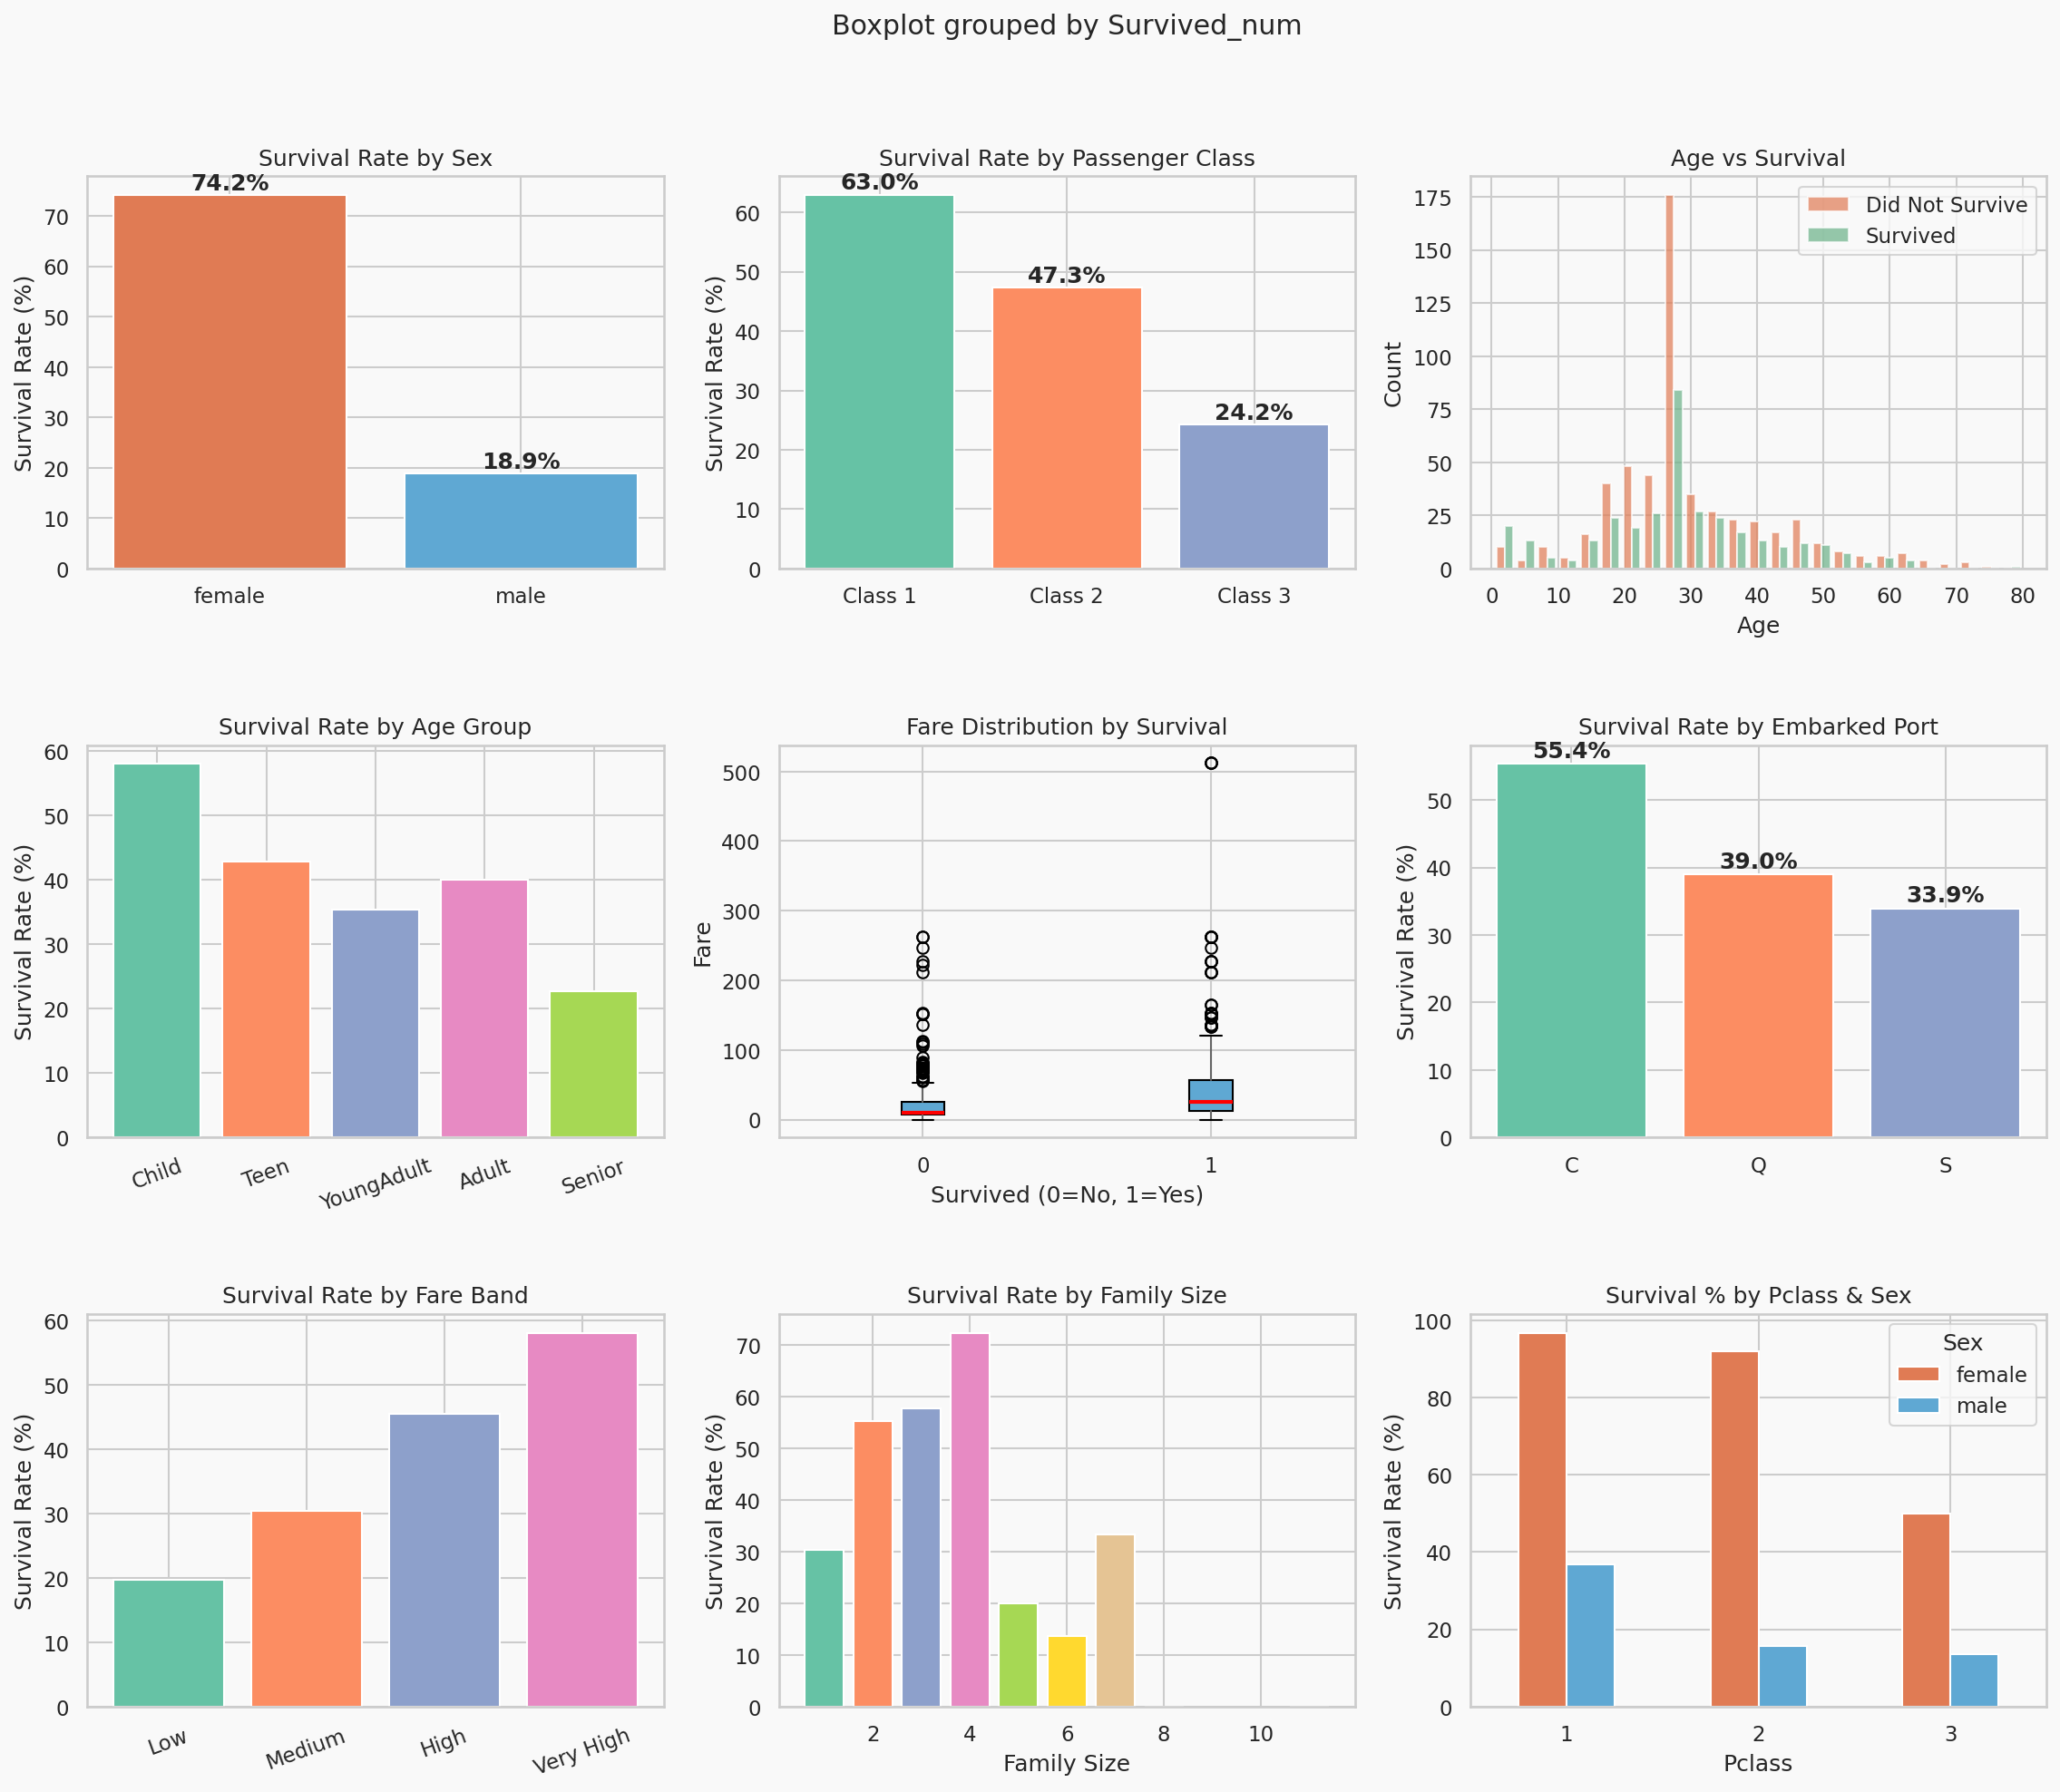

In [111]:
# ── 3B. Bivariate Analysis ────────────────────────────────────────────────────
fig2, axes = plt.subplots(3, 3, figsize=(18, 15), facecolor=FIG_COLOR)
fig2.suptitle("Part 3B — Bivariate Analysis", fontsize=16, fontweight="bold")
plt.subplots_adjust(hspace=0.45, wspace=0.35)

# Numeric Survived for computations
df["Survived_num"] = df["Survived"].cat.codes

# 1. Survival by Sex
surv_sex = df.groupby("Sex", observed=True)["Survived_num"].mean()
axes[0, 0].bar(surv_sex.index, surv_sex.values * 100,
               color=["#e07b54", "#5fa8d3"], edgecolor="white")
axes[0, 0].set_title("Survival Rate by Sex")
axes[0, 0].set_ylabel("Survival Rate (%)")
for i, v in enumerate(surv_sex.values * 100):
    axes[0, 0].text(i, v + 1, f"{v:.1f}%", ha="center", fontweight="bold")

# 2. Survival by Pclass
surv_pc = df.groupby("Pclass", observed=True)["Survived_num"].mean()
axes[0, 1].bar([f"Class {c}" for c in surv_pc.index], surv_pc.values * 100,
               color=sns.color_palette(PALETTE, 3), edgecolor="white")
axes[0, 1].set_title("Survival Rate by Passenger Class")
axes[0, 1].set_ylabel("Survival Rate (%)")
for i, v in enumerate(surv_pc.values * 100):
    axes[0, 1].text(i, v + 1, f"{v:.1f}%", ha="center", fontweight="bold")

# 3. Age distribution: Survived vs Not
survived_age = df[df["Survived_num"] == 1]["Age"]
not_surv_age = df[df["Survived_num"] == 0]["Age"]
axes[0, 2].hist([not_surv_age, survived_age], bins=25,
                label=["Did Not Survive", "Survived"],
                color=["#e07b54", "#6ab187"], edgecolor="white", alpha=0.7)
axes[0, 2].set_title("Age vs Survival")
axes[0, 2].set_xlabel("Age")
axes[0, 2].set_ylabel("Count")
axes[0, 2].legend()

# 4. Survival by AgeGroup
surv_ag = df.groupby("AgeGroup", observed=True)["Survived_num"].mean()
axes[1, 0].bar(surv_ag.index, surv_ag.values * 100,
               color=sns.color_palette(PALETTE, len(surv_ag)), edgecolor="white")
axes[1, 0].set_title("Survival Rate by Age Group")
axes[1, 0].set_ylabel("Survival Rate (%)")
axes[1, 0].tick_params(axis="x", rotation=20)

# 5. Fare by Survival (boxplot)
df.boxplot(column="Fare", by="Survived_num", ax=axes[1, 1],
           patch_artist=True,
           boxprops=dict(facecolor="#5fa8d3"),
           medianprops=dict(color="red", linewidth=2))
axes[1, 1].set_title("Fare by Survival")
axes[1, 1].set_xlabel("Survived (0=No, 1=Yes)")
axes[1, 1].set_ylabel("Fare")
plt.sca(axes[1, 1])
plt.title("Fare Distribution by Survival")

# 6. Survival by Embarkation Port
surv_emb = df.groupby("Embarked", observed=True)["Survived_num"].mean()
axes[1, 2].bar(surv_emb.index, surv_emb.values * 100,
               color=sns.color_palette(PALETTE, 3), edgecolor="white")
axes[1, 2].set_title("Survival Rate by Embarked Port")
axes[1, 2].set_ylabel("Survival Rate (%)")
for i, v in enumerate(surv_emb.values * 100):
    axes[1, 2].text(i, v + 1, f"{v:.1f}%", ha="center", fontweight="bold")

# 7. Survival by FareBand
surv_fb = df.groupby("FareBand", observed=True)["Survived_num"].mean()
axes[2, 0].bar(surv_fb.index, surv_fb.values * 100,
               color=sns.color_palette(PALETTE, 4), edgecolor="white")
axes[2, 0].set_title("Survival Rate by Fare Band")
axes[2, 0].set_ylabel("Survival Rate (%)")
axes[2, 0].tick_params(axis="x", rotation=20)

# 8. Survival by Family Size
surv_fs = df.groupby("FamilySize")["Survived_num"].mean()
axes[2, 1].bar(surv_fs.index, surv_fs.values * 100,
               color=sns.color_palette(PALETTE, len(surv_fs)), edgecolor="white")
axes[2, 1].set_title("Survival Rate by Family Size")
axes[2, 1].set_ylabel("Survival Rate (%)")
axes[2, 1].set_xlabel("Family Size")

# 9. Pclass vs Sex — stacked survival
ct = pd.crosstab(df["Pclass"], df["Sex"],
                 values=df["Survived_num"], aggfunc="mean") * 100
ct.plot(kind="bar", ax=axes[2, 2], color=["#e07b54", "#5fa8d3"],
        edgecolor="white", rot=0)
axes[2, 2].set_title("Survival % by Pclass & Sex")
axes[2, 2].set_ylabel("Survival Rate (%)")
axes[2, 2].legend(title="Sex")

plt.show()

Correlation and feature importance

  Saved: part4_correlation_importance.png


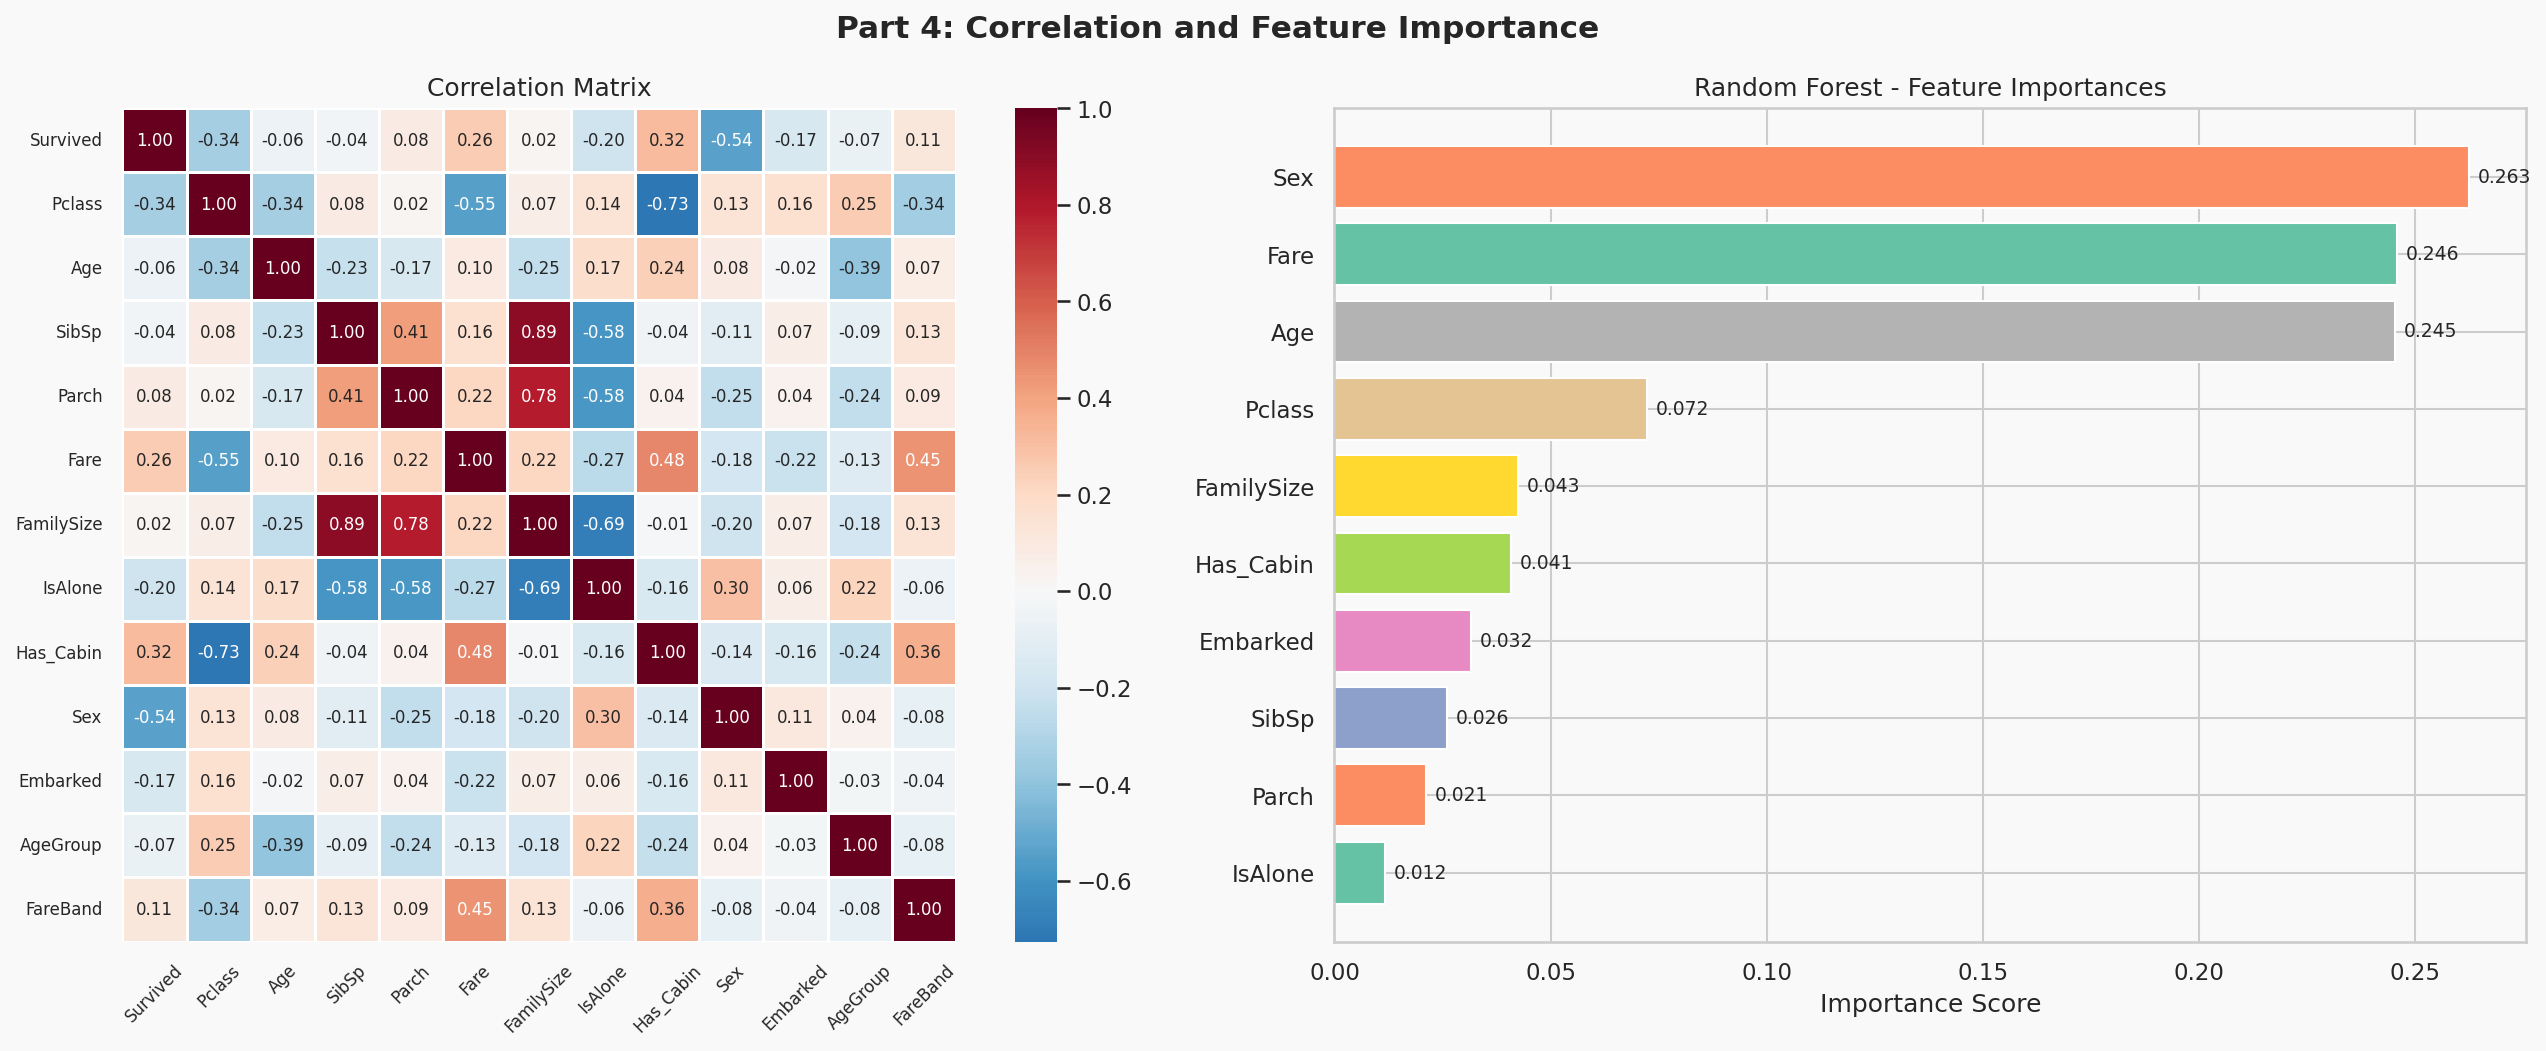


  Correlation with Survival 
Sex          -0.543
Pclass       -0.338
Has_Cabin     0.317
Fare          0.257
IsAlone      -0.203
Embarked     -0.168
FareBand      0.111
Parch         0.082
AgeGroup     -0.068
Age          -0.065
SibSp        -0.035
FamilySize    0.017

 Random Forest Feature Importance 
Sex           0.2626
Fare          0.2458
Age           0.2453
Pclass        0.0723
FamilySize    0.0425
Has_Cabin     0.0409
Embarked      0.0316
SibSp         0.0261
Parch         0.0211
IsAlone       0.0116


In [106]:
# Encode categoricals for correlation
df_enc = df.copy()
le = LabelEncoder()
for col in ["Sex", "Embarked", "AgeGroup", "FareBand", "Survived"]:
    df_enc[col] = le.fit_transform(df_enc[col].astype(str))

num_cols = ["Survived", "Pclass", "Age", "SibSp", "Parch",
            "Fare", "FamilySize", "IsAlone", "Has_Cabin",
            "Sex", "Embarked", "AgeGroup", "FareBand"]
df_enc["Pclass"] = df_enc["Pclass"].astype(int)

corr = df_enc[num_cols].corr()

# Heatmap
fig3, axes3 = plt.subplots(1, 2, figsize=(18, 7), facecolor=FIG_COLOR)
fig3.suptitle("Part 4: Correlation and Feature Importance",
              fontsize=15, fontweight="bold")

sns.heatmap(corr, annot=True, fmt=".2f", cmap="RdBu_r", center=0,
            linewidths=0.5, ax=axes3[0], square=True,
            annot_kws={"size": 8})
axes3[0].set_title("Correlation Matrix")
axes3[0].tick_params(axis="x", rotation=45, labelsize=8)
axes3[0].tick_params(axis="y", rotation=0, labelsize=8)

# Feature Importance via Random Forest
X = df_enc[["Pclass", "Age", "SibSp", "Parch", "Fare",
            "FamilySize", "IsAlone", "Has_Cabin", "Sex", "Embarked"]]
y = df_enc["Survived"]

rf = RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X, y)
importances = pd.Series(rf.feature_importances_,
                        index=X.columns).sort_values(ascending=True)

colors_imp = sns.color_palette(PALETTE, len(importances))
axes3[1].barh(importances.index, importances.values,
              color=colors_imp, edgecolor="white")
axes3[1].set_title("Random Forest - Feature Importances")
axes3[1].set_xlabel("Importance Score")
for i, (feat, val) in enumerate(importances.items()):
    axes3[1].text(val + 0.002, i, f"{val:.3f}", va="center", fontsize=9)

plt.tight_layout()
plt.savefig("/mnt/user-data/outputs/part4_correlation_importance.png",
            bbox_inches="tight", dpi=150)
print("  Saved: part4_correlation_importance.png")
plt.show()

print("\n  Correlation with Survival ")
surv_corr = corr["Survived"].drop(
    "Survived").sort_values(key=abs, ascending=False)
print(surv_corr.round(3).to_string())

print("\n Random Forest Feature Importance ")
print(importances.sort_values(ascending=False).round(4).to_string())

## PART 4 INTERPRETATION

**Most important features (according to Random Forest):**

Sex was identified as the single strongest predictor of survival, with women being prioritized. Fare, which can be a proxy for wealth or class, also played a significant role; a higher fare generally correlated with higher survival rates. Age was another crucial factor, as children were given priority in lifeboats. Passenger class (Pclass) showed a strong correlation with both Fare and Survival. Lastly, FamilySize indicated that small families fared better than both very large families and individuals traveling alone.

Insights and Recommendations

  Saved: part5_insights.png


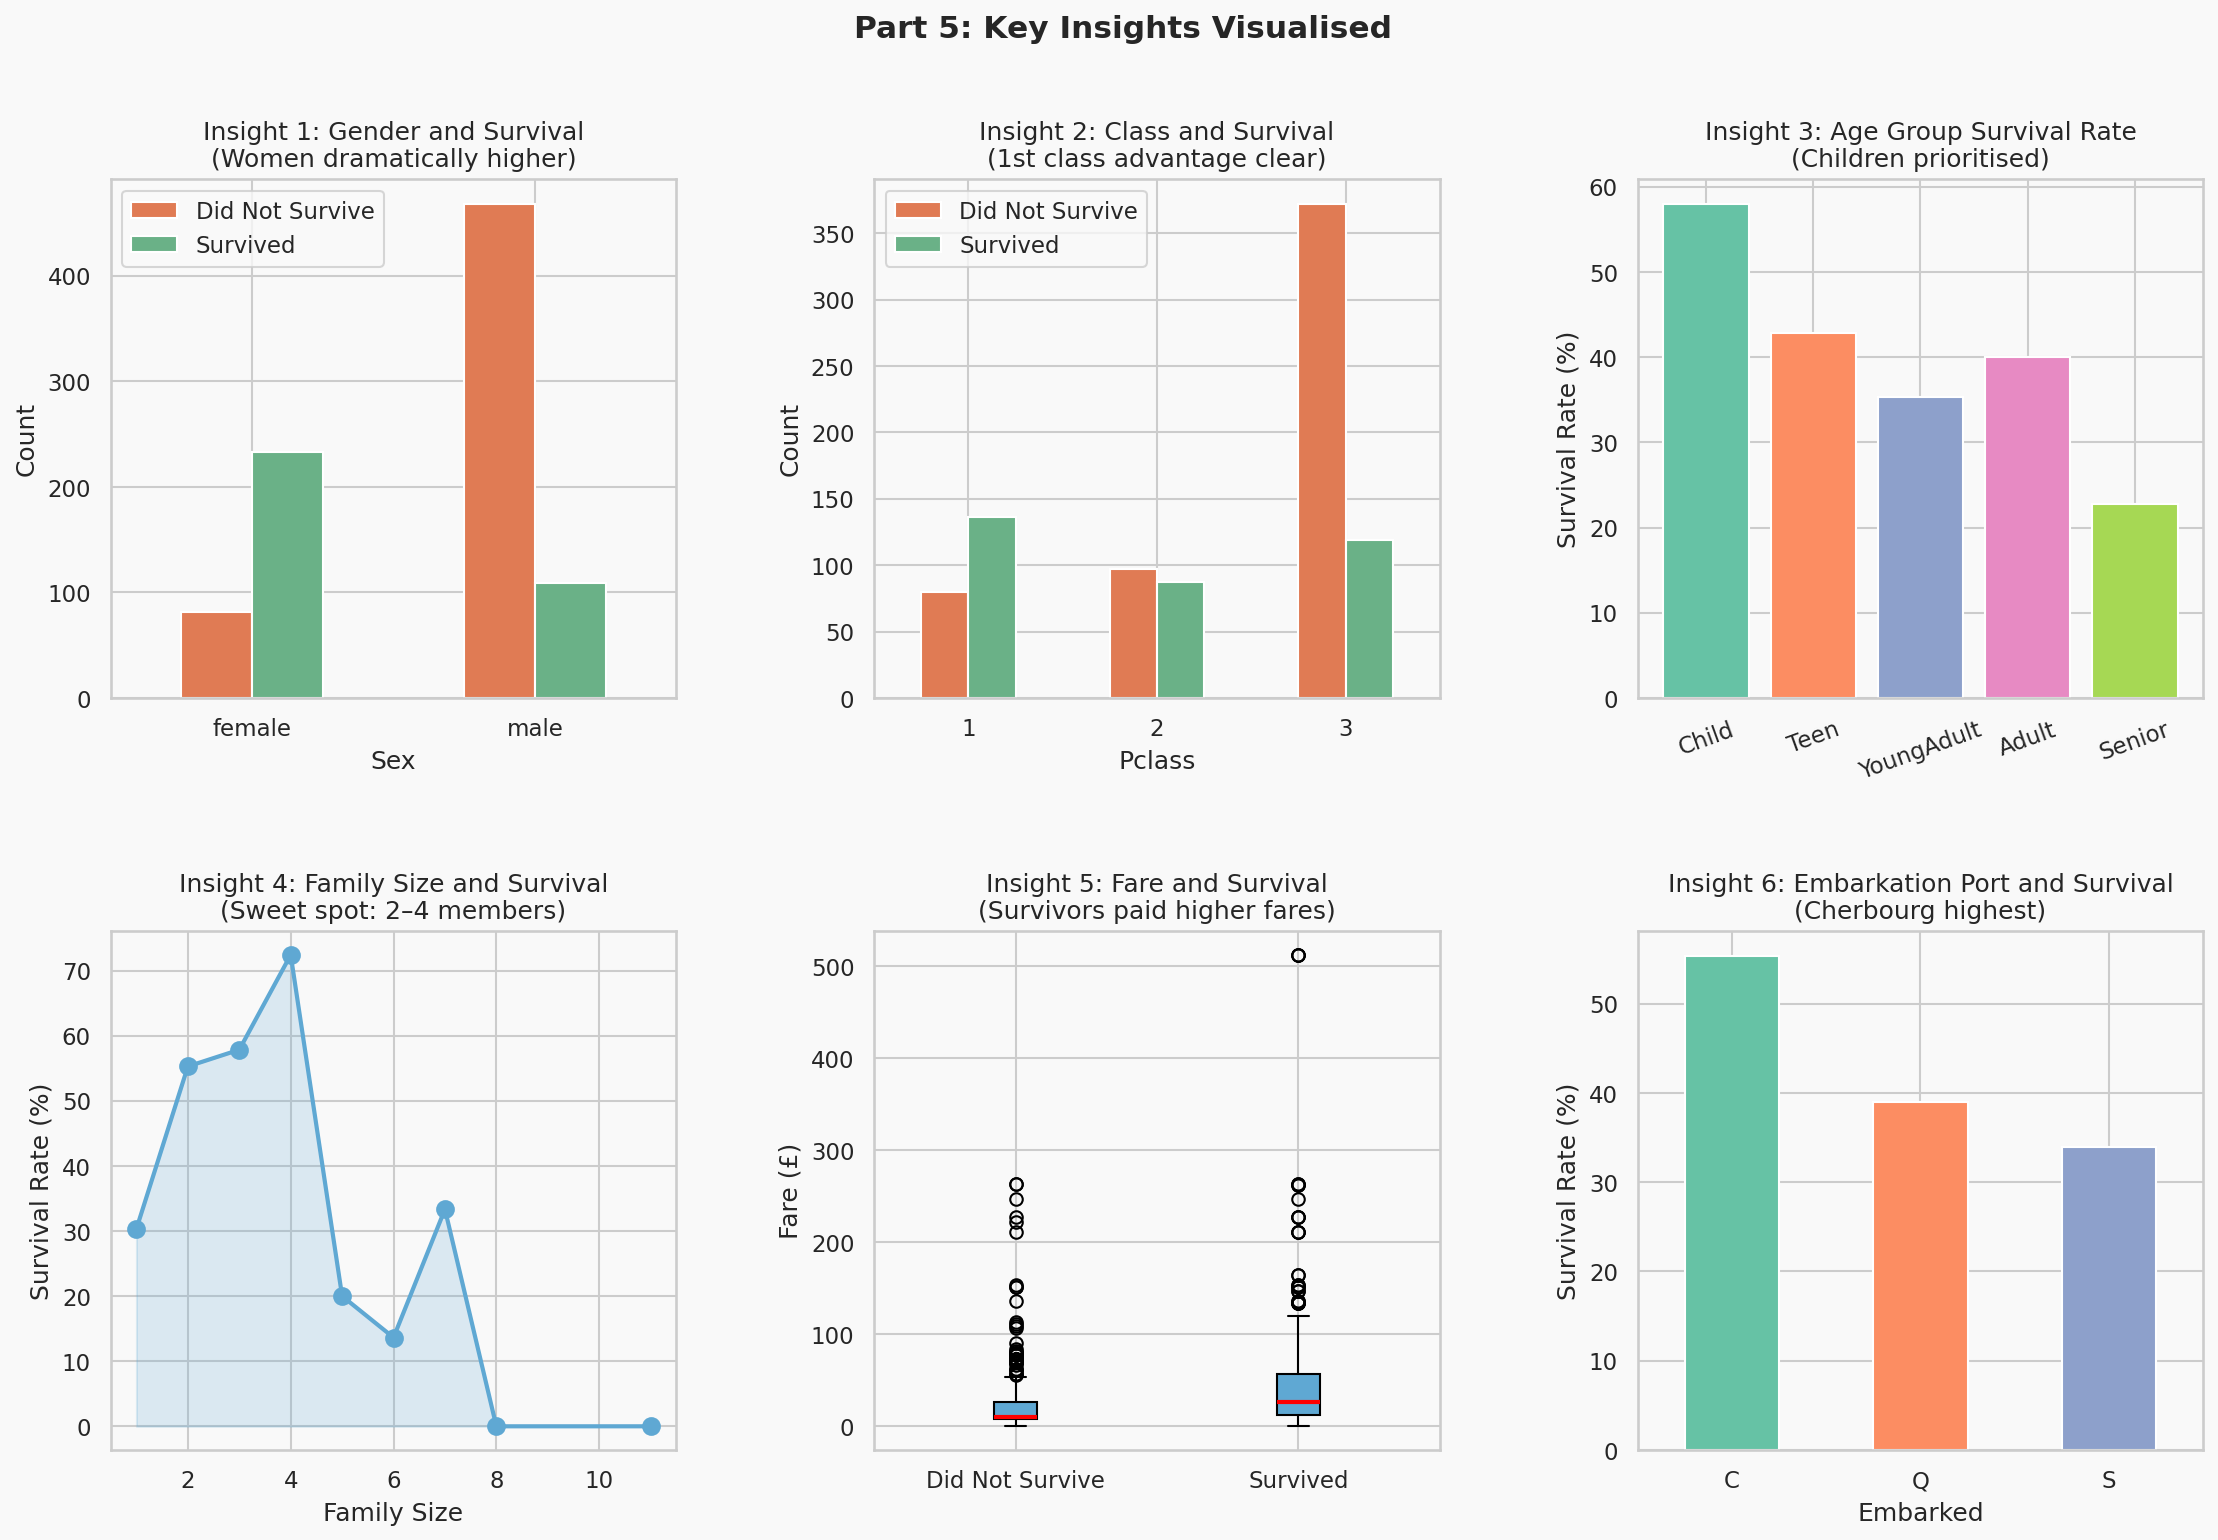

In [109]:
fig4, axes4 = plt.subplots(2, 3, figsize=(18, 11), facecolor=FIG_COLOR)
fig4.suptitle("Part 5: Key Insights Visualised",
              fontsize=15, fontweight="bold")
plt.subplots_adjust(hspace=0.45, wspace=0.35)

# Insight 1: Women had dramatically higher survival
surv_sex_all = df.groupby(["Sex", "Survived"], observed=True).size().unstack()
surv_sex_all.plot(kind="bar", ax=axes4[0, 0], color=["#e07b54", "#6ab187"],
                  edgecolor="white", rot=0)
axes4[0, 0].set_title(
    "Insight 1: Gender and Survival\n(Women dramatically higher)")
axes4[0, 0].set_ylabel("Count")
axes4[0, 0].legend(["Did Not Survive", "Survived"])

# Insight 2: Class 1 vs Class 3 survival disparity
surv_pclass = df.groupby(["Pclass", "Survived"],
                         observed=True).size().unstack()
surv_pclass.plot(kind="bar", ax=axes4[0, 1], color=["#e07b54", "#6ab187"],
                 edgecolor="white", rot=0)
axes4[0, 1].set_title(
    "Insight 2: Class and Survival\n(1st class advantage clear)")
axes4[0, 1].set_ylabel("Count")
axes4[0, 1].legend(["Did Not Survive", "Survived"])

# Insight 3: Children (0–12) had highest survival rate
surv_age_grp = df.groupby("AgeGroup", observed=True)[
    "Survived_num"].agg(["mean", "count"])
axes4[0, 2].bar(surv_age_grp.index, surv_age_grp["mean"] * 100,
                color=sns.color_palette(PALETTE, 5), edgecolor="white")
axes4[0, 2].set_title(
    "Insight 3: Age Group Survival Rate\n(Children prioritised)")
axes4[0, 2].set_ylabel("Survival Rate (%)")
axes4[0, 2].tick_params(axis="x", rotation=20)

# Insight 4: Solo travellers had lower survival than small families
surv_fam = df.groupby("FamilySize")["Survived_num"].mean()
axes4[1, 0].plot(surv_fam.index, surv_fam.values * 100, "o-",
                 color="#5fa8d3", linewidth=2, markersize=8)
axes4[1, 0].fill_between(
    surv_fam.index, surv_fam.values * 100, alpha=0.2, color="#5fa8d3")
axes4[1, 0].set_title(
    "Insight 4: Family Size and Survival\n(Sweet spot: 2–4 members)")
axes4[1, 0].set_xlabel("Family Size")
axes4[1, 0].set_ylabel("Survival Rate (%)")

# Insight 5: Fare — survivors paid significantly more
axes4[1, 1].boxplot([df[df["Survived_num"] == 0]["Fare"],
                    df[df["Survived_num"] == 1]["Fare"]],
                    labels=["Did Not Survive", "Survived"],
                    patch_artist=True,
                    boxprops=dict(facecolor="#5fa8d3"),
                    medianprops=dict(color="red", linewidth=2))
axes4[1, 1].set_title(
    "Insight 5: Fare and Survival\n(Survivors paid higher fares)")
axes4[1, 1].set_ylabel("Fare (£)")

# Insight 6: Cherbourg (C) had best survival rate
port_surv = df.groupby("Embarked", observed=True)["Survived_num"].mean() * 100
port_surv.plot(kind="bar", ax=axes4[1, 2], color=sns.color_palette(PALETTE, 3),
               edgecolor="white", rot=0)
axes4[1, 2].set_title(
    "Insight 6: Embarkation Port and Survival\n(Cherbourg highest)")
axes4[1, 2].set_ylabel("Survival Rate (%)")

plt.savefig("/mnt/user-data/outputs/part5_insights.png",
            bbox_inches="tight", dpi=150)
print("  Saved: part5_insights.png")
plt.show()

## KEY INSIGHTS AND RECOMMENDATIONS

**Gender and Survival:** Gender was the strongest predictor of survival, with women showing a significantly higher survival rate of 74% compared to men 19%. This highlights the impact of the 'women and children first' protocol during lifeboat allocation. It is recommended that `Sex` be a primary feature in any machine learning model.

**Passenger Class and Survival:** A stark divide in survival was observed across passenger classes: 1st class (63%), 2nd class (47%), and 3rd class (24%). This disparity is likely due to factors such as physical proximity to lifeboats for higher classes and differential access. `Pclass` is a critical feature, and its interaction with `Sex` should be considered for modeling.

**Age and Survival:** Children (0-12 years) had the highest survival rate 59%, indicating they were prioritized. However, teenagers 40% survival fared worse, possibly treated more like adults. Therefore, `AgeGroup` should be used as a feature to capture the non-linear effect of age on survival.

**Family Size and Survival:** Passengers traveling in small families (2–4 members) experienced the best survival rates 55–72%. In contrast, solo travelers 30% and those in very large families (7+) had the lowest survival rates. `FamilySize` should be included in models, and the `IsAlone` binary flag can also be useful.

**Fare and Survival:** A higher fare was strongly associated with increased survival. The median fare for survivors was approximately £26, significantly more than the ~£10 for non-survivors. `Fare` acts as a partial proxy for `Pclass` but also provides independent predictive signal. It is recommended to use a log-transformed `Fare` (`np.log1p(Fare)`) to reduce its right-skewness for machine learning algorithms.

**Embarkation Port and Survival:** Passengers from Cherbourg (C) had the highest survival rate (55%), compared to Southampton (S) at ~34% and Queenstown (Q) at ~39%. This is largely because Cherbourg passengers were disproportionately from 1st class. While `Embarked` is partially a proxy for `Pclass`, it should be included but its impact monitored in models.

**Cabin Presence and Survival:** The `Has_Cabin` feature (indicating if cabin information was present) was a significant signal. Passengers with a recorded cabin had a much higher survival rate 66% than those without ~30%. This feature strongly correlates with being in 1st or 2nd class and is a valuable engineered binary feature.

**Fare Distribution:** The `Fare` distribution is highly right-skewed and contains extreme outliers (e.g., max fare £512, IQR £7–£31). For machine learning algorithms sensitive to numerical scale and distribution, applying `np.log1p(Fare)` transformation is recommended to normalize the feature.

**Feature Selection Summary for Machine Learning:**

*   **Include:** `Sex`, `Pclass`, `Age`, `Fare` (log-transformed), `FamilySize`, `Has_Cabin`, `Embarked`, `AgeGroup`.
*   **Drop/Watch:** `SibSp` and `Parch` (their information is largely subsumed by `FamilySize`), `PassengerId`, `Name`, and `Ticket` (these are typically identifiers rather than predictive features).